# Visión por Computadora
## Clase 1 — Introducción y formación de la imagen
### Unidad 1 · Fundamentos y características visuales

**Laboratorio práctico.** Este curso te llevará a construir modelos de deep learning que
interpretan imágenes. Pero antes de que una red neuronal pueda “ver”, hay que entender
qué recibe. En este cuaderno vas a cargar imágenes, entenderlas como arreglos,
recorrer sus canales de color y convertirlas entre espacios (RGB, escala de grises, HSV).

**Entorno:** Jupyter local (Anaconda). Si algo no está instalado, la primera celda lo resuelve.

**Docente:** Jorge Arevalo

---
## Parte 0 · Nivelación exprés de NumPy 

Una imagen no es más que un arreglo de números. Antes de tocar imágenes, aseguremos
el manejo mínimo de NumPy: `shape`, indexación y *slicing*. 

In [1]:
# Instala las librerías solo si faltan (en Anaconda suelen venir preinstaladas)
import sys, subprocess

def ensure(package, import_name=None):
    name = import_name or package
    try:
        __import__(name)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", package], check=True)

for pkg, imp in [("numpy", "numpy"), ("opencv-python", "cv2"), ("matplotlib", "matplotlib"), ("ipywidgets", "ipywidgets")]:
    ensure(pkg, imp)

print("Librerías listas.")


Librerías listas.


In [2]:
import numpy as np

# Un arreglo 2D pequeño hace de "imagen de juguete": cada número es la intensidad de un píxel
toy = np.array([[  0,  50, 100],
                [150, 200, 255],
                [ 30,  60,  90]], dtype=np.uint8)

print("Arreglo:")
print(toy)
print("shape (filas, columnas):", toy.shape)   # (3, 3)
print("tipo de dato:", toy.dtype)               # uint8 = enteros 0..255


Arreglo:
[[  0  50 100]
 [150 200 255]
 [ 30  60  90]]
shape (filas, columnas): (3, 3)
tipo de dato: uint8


**Predice antes de ejecutar:** ¿qué número imprime cada una de las siguientes líneas?

In [3]:
# Indexación: [fila, columna], empezando en 0
print("píxel fila 0, col 0:", toy[0, 0])   # esquina superior izquierda
print("píxel fila 1, col 2:", toy[1, 2])   # ¿cuál es?

# Slicing: seleccionar una región [fila_ini:fila_fin, col_ini:col_fin]
print("primera fila completa:", toy[0, :])
print("primera columna completa:", toy[:, 0])
print("sub-bloque 2x2 superior izquierdo:")
print(toy[0:2, 0:2])


píxel fila 0, col 0: 0
píxel fila 1, col 2: 255
primera fila completa: [  0  50 100]
primera columna completa: [  0 150  30]
sub-bloque 2x2 superior izquierdo:
[[  0  50]
 [150 200]]


**Idea clave:** `arreglo[fila, columna]` accede a un píxel; `arreglo[a:b, c:d]`
recorta una región. Exactamente lo mismo que harás con imágenes reales de aquí en adelante.


---
## Parte 1 · Sube tu propia imagen

Todo el laboratorio trabaja sobre **una foto tuya**. El proceso son tres pasos:

1. Ejecuta la **celda A**: aparece el botón **Subir foto**. Púlsalo y elige una imagen.
   Cuando el botón muestre un `(1)`, tu archivo ya está cargado.
2. Ejecuta la **celda B**: lee esa imagen y la muestra. Notarás algo raro con los colores.
3. Piensa por qué, y recién entonces ejecuta la **celda C**, que lo explica y lo corrige.



**Celda A — muestra el botón y elige tu foto.**

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# La imagen vivirá en estas variables, en MEMORIA (no en un archivo):
#   work_bgr -> como la lee OpenCV (orden BGR)
#   work_rgb -> convertida para mostrar con Matplotlib (orden RGB)
work_bgr = None
work_rgb = None

uploader = widgets.FileUpload(accept="image/*", multiple=False, description="Subir foto")
display(uploader)
print("1) Pulsa 'Subir foto' y elige una imagen.")
print("2) Cuando el botón muestre (1), ejecuta la celda B de abajo.")


FileUpload(value=(), accept='image/*', description='Subir foto')

1) Pulsa 'Subir foto' y elige una imagen.
2) Cuando el botón muestre (1), ejecuta la celda B de abajo.


**Celda B — lee la foto y muéstrala.** Ejecútala *después* de elegir el archivo
arriba. Si la cambias, vuelve a pulsar el botón y ejecuta esta celda otra vez.


shape (alto, ancho, canales): (647, 647, 3)  | tipo: uint8


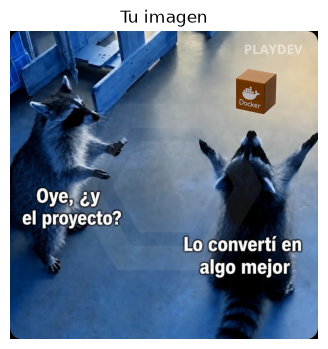

In [4]:
def leer_upload(uploader):
    # Compatibilidad entre versiones de ipywidgets:
    #   v8 -> uploader.value es una tupla de dicts
    #   v7 -> uploader.value es un dict {nombre: {...}}
    val = uploader.value
    if not val:
        return None
    item = val[0] if isinstance(val, (list, tuple)) else list(val.values())[0]
    datos = item["content"]
    datos = datos.tobytes() if hasattr(datos, "tobytes") else bytes(datos)
    buffer = np.frombuffer(datos, dtype=np.uint8)
    return cv2.imdecode(buffer, cv2.IMREAD_COLOR)   # decodifica en memoria (BGR)

work_bgr = leer_upload(uploader)

if work_bgr is None:
    print("Aún no hay imagen. Sube una en la celda A (el botón debe mostrar (1)) y vuelve a ejecutar esta celda.")
else:
    print("shape (alto, ancho, canales):", work_bgr.shape, " | tipo:", work_bgr.dtype)
    # Mostramos el arreglo TAL CUAL lo entregó OpenCV, sin convertir nada.
    plt.figure(figsize=(6, 4))
    plt.imshow(work_bgr)
    plt.title("Tu imagen")
    plt.axis("off")
    plt.show()


### Para pensar antes de seguir

¿Notas algo **raro** con los colores de tu foto? Un cielo azul se ve rojizo, el pasto puede verse extraño…

**Con lo que vimos en la teoría, ¿por qué crees que pasa esto?** 


**Celda C — la explicación y el arreglo.** 


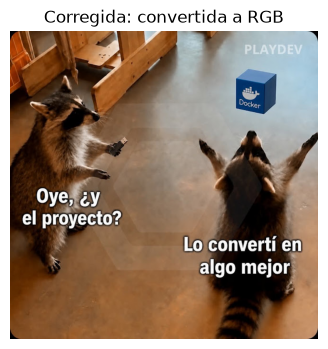

Misma imagen, mismos datos. La única diferencia fue reordenar los canales.


In [5]:
# La razón: cv2 carga los canales en orden BGR (Azul, Verde, Rojo), pero Matplotlib
# los interpreta como RGB (Rojo, Verde, Azul). Al no coincidir, el rojo y el azul quedan
# intercambiados. La solución es reordenarlos con cvtColor:
work_rgb = cv2.cvtColor(work_bgr, cv2.COLOR_BGR2RGB)   # BGR -> RGB

plt.figure(figsize=(6, 4))
plt.imshow(work_rgb)                 # ahora sí, colores correctos
plt.title("Corregida: convertida a RGB")
plt.axis("off")
plt.show()

print("Misma imagen, mismos datos. La única diferencia fue reordenar los canales.")


¿Le atinaste? Este es, de lejos, el error más común al empezar con OpenCV: cargas
una foto, la muestras y los colores salen cambiados. La causa es siempre la misma
(**BGR vs RGB**) y la cura es una línea: `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`.

De aquí en adelante, `work_rgb` es tu imagen con los colores correctos.


> Si el botón de subir no aparece, en una celda nueva ejecuta `!pip install ipywidgets`
> y reinicia el kernel (menú Kernel → Restart).


In [6]:
# Verificación: asegura que hay una imagen cargada antes de los siguientes pasos.
assert work_bgr is not None, "Todavía no hay imagen. Sube una foto (celda A) y ejecuta la celda B."
print("Imagen lista. shape:", work_bgr.shape)


Imagen lista. shape: (647, 647, 3)


Fíjate en el `shape`: una imagen a color es un arreglo de tres dimensiones,
**(alto, ancho, 3)**. Ese 3 son los canales rojo, verde y azul.


---
## Parte 2 · Separar los canales de color

Una imagen a color son tres capas apiladas. Vamos a separarlas y mirarlas por separado.
Cada canal es una imagen en escala de grises que indica *cuánto* de ese color hay en cada píxel.


shape de un canal: (647, 647)


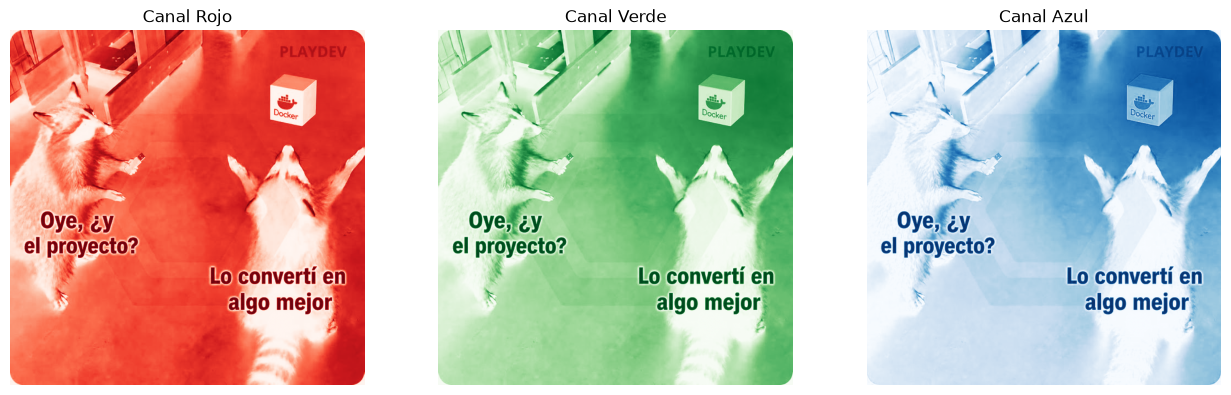

In [10]:
# Separamos los tres canales del arreglo RGB
R = work_rgb[:, :, 0]   # canal rojo
G = work_rgb[:, :, 1]   # canal verde
B = work_rgb[:, :, 2]   # canal azul

print("shape de un canal:", R.shape)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, canal, nombre, cmap in zip(
        axes, [R, G, B], ["Rojo", "Verde", "Azul"], ["Reds", "Greens", "Blues"]):
    ax.imshow(canal, cmap=cmap)
    ax.set_title(f"Canal {nombre}")
    ax.axis("off")
plt.tight_layout()
plt.show()


---
## Parte 3 · Convertir a escala de grises

Pasar a grises reduce los tres canales a uno solo. No es un simple promedio: se pondera
más el verde porque el ojo humano es más sensible a él.


shape en color: (647, 647, 3)
shape en grises: (647, 647)  -> perdimos la dimensión de canales


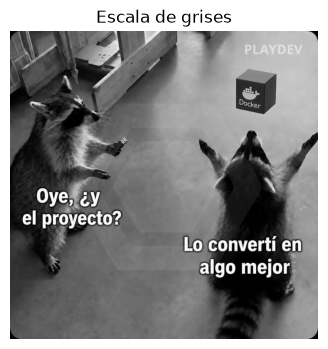

In [11]:
gray = cv2.cvtColor(work_bgr, cv2.COLOR_BGR2GRAY)  # nota: se convierte desde BGR

print("shape en color:", work_rgb.shape)
print("shape en grises:", gray.shape, " -> perdimos la dimensión de canales")

plt.figure(figsize=(6, 4))
plt.imshow(gray, cmap="gray")
plt.title("Escala de grises")
plt.axis("off")
plt.show()


**Qué se pierde:** al pasar a grises se descarta toda la información de color.
Para muchas tareas (detección de bordes, umbralización) eso es justo lo que queremos,
porque simplifica el problema. En otras (distinguir una fruta madura de una verde) el
color es esencial.


---
## Parte 4 · El espacio HSV

RGB mezcla color e intensidad. **HSV** los separa en tono (*Hue*), saturación
(*Saturation*) y valor/brillo (*Value*).


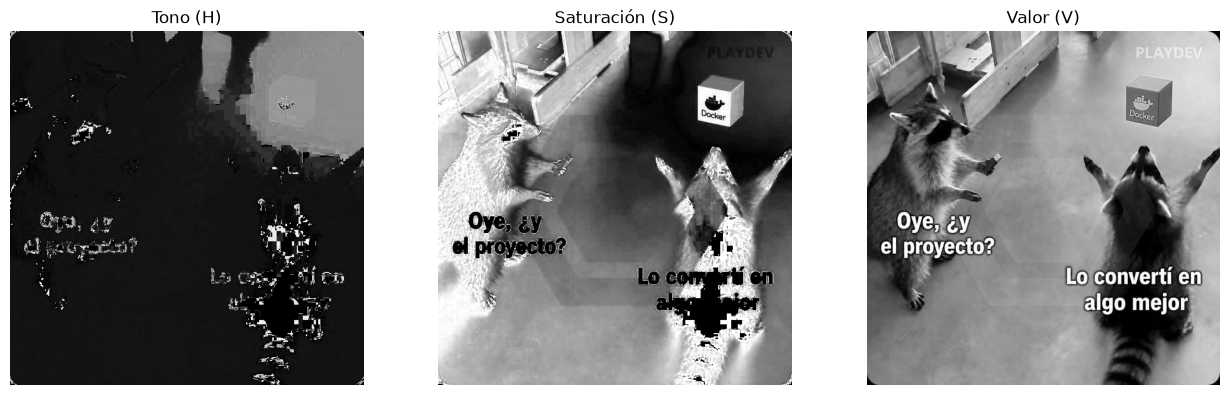

In [12]:
hsv = cv2.cvtColor(work_bgr, cv2.COLOR_BGR2HSV)

H = hsv[:, :, 0]   # tono: 0..179 en OpenCV (se calcula en angulos en base al circulo del color) (no llega a 360)
S = hsv[:, :, 1]   # saturación: 0..255 (se calcular en proporciones) 
V = hsv[:, :, 2]   # valor/brillo: 0..255 (se calcular en proporciones) 

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, canal, nombre in zip(axes, [H, S, V], ["Tono (H)", "Saturación (S)", "Valor (V)"]):
    ax.imshow(canal, cmap="gray")
    ax.set_title(nombre)
    ax.axis("off")
plt.tight_layout()
plt.show()


> En OpenCV el tono va de **0 a 179** , porque se guarda en 8 bits.
> Es un detalle que confunde a muchos la primera vez.


In [8]:
---
## Parte 5 · Manipular píxeles y regiones

Como una imagen es un arreglo, podemos modificarla con indexación y *slicing*.

SyntaxError: invalid syntax (3514616583.py, line 1)

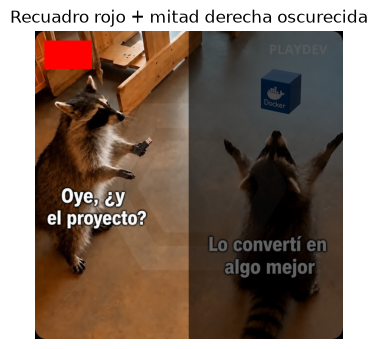

In [9]:
demo = work_rgb.copy()   # trabajamos sobre una copia para no dañar el original

h, w = demo.shape[:2]

# 1) Pintar un recuadro de color sólido usando slicing
demo[20:80, 20:120] = [255, 0, 0]   # rectángulo rojo (RGB)

# 2) Oscurecer la mitad derecha multiplicando sus valores
demo[:, w//2:] = (demo[:, w//2:] * 0.4).astype(np.uint8)  #toda la fila --- ancho "//" (entre) 2 --- 0.4 (40% de oscurecimiento) 
                                                                                               # --- 0% es negro - 100% transparente 

plt.figure(figsize=(6, 4))
plt.imshow(demo)
plt.title("Recuadro rojo + mitad derecha oscurecida")
plt.axis("off")
plt.show()


---
## Ejercicio de la sesión — TU TURNO

**Objetivo:** convertir tu imagen entre espacios de color y explicar qué información
se pierde o se resalta en cada uno.

Completa los pasos:

1. Muestra tu imagen de trabajo en **RGB**, **escala de grises** y **HSV**, una al lado de la otra.
2. Recorta con *slicing* una región de **100×100 píxeles** de tu imagen y muéstrala.
3. Responde en la celda de texto final: ¿qué información se perdió al pasar a grises?
   ¿Para qué tarea sería útil el canal de saturación (S) de HSV?


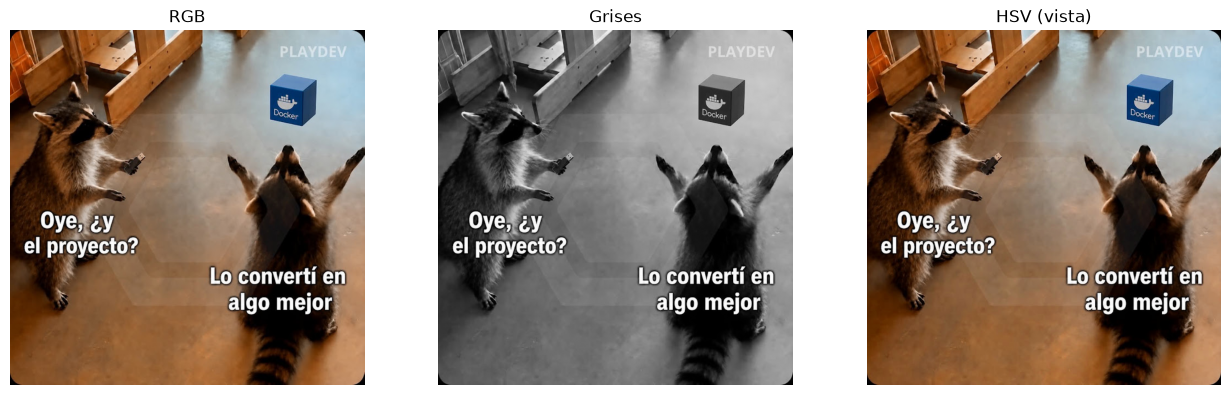

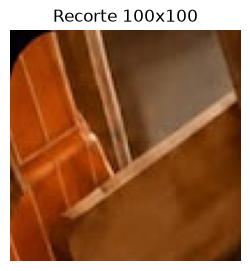

In [10]:
# TU TURNO: completa el código

# Paso 1 — tres versiones lado a lado
mi_rgb  = work_rgb
mi_gray = cv2.cvtColor(work_bgr, cv2.COLOR_BGR2GRAY)
mi_hsv  = cv2.cvtColor(work_bgr, cv2.COLOR_BGR2HSV)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(mi_rgb);                axes[0].set_title("RGB");    axes[0].axis("off")
axes[1].imshow(mi_gray, cmap="gray");  axes[1].set_title("Grises"); axes[1].axis("off")

# Para "ver" HSV como imagen se suele mostrar convertido de vuelta a RGB solo para visualizar:
axes[2].imshow(cv2.cvtColor(mi_hsv, cv2.COLOR_HSV2RGB)); axes[2].set_title("HSV (vista)"); axes[2].axis("off")
plt.tight_layout(); plt.show()

# Paso 2 — recorta una región de 100x100 (elige tú el punto de inicio)
y0, x0 = 0, 0                      # <-- cambia estos valores
recorte = mi_rgb[y0:y0+100, x0:x0+100]
plt.figure(figsize=(3, 3))
plt.imshow(recorte); plt.title("Recorte 100x100"); plt.axis("off"); plt.show()


### Paso 3 — Tus respuestas (escribe aquí)

**¿Qué información se perdió al pasar a grises?**

*(tu respuesta)*

**¿Para qué tarea sería útil el canal de saturación (S) de HSV?**

*(tu respuesta)*


---
### Cierre de la Clase 1

Hoy viste que una imagen es un arreglo de números, cómo cargarla y mostrarla evitando
el lío BGR/RGB, cómo separar canales y cómo moverte entre RGB, grises y HSV.

**¿Por qué importa esto para el resto del curso?** Porque cuando lleguemos a las redes
neuronales convolucionales, ellas operarán exactamente sobre estos mismos arreglos donde cada
capa toma esta matriz de números y la transforma. Entender la imagen como dato es el
primer paso para entender cómo una máquina aprende a interpretarla.

